<a href="https://colab.research.google.com/github/Amirtha-19/Air_Quality_Prediction/blob/main/Predicting_air_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("air_quality_dataset.csv")
df.head()

,Temperature,Humidity,NO2,SO2,CO,PM2.5
0,32,65,28,12,0.8,45
1,30,70,25,10,0.7,40
2,35,55,35,15,1.0,60
3,29,75,20,8,0.6,35
4,33,60,30,13,0.9,50


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  170 non-null    int64  
 1   Humidity     170 non-null    int64  
 2   NO2          170 non-null    int64  
 3   SO2          170 non-null    int64  
 4   CO           170 non-null    float64
 5   PM2.5        170 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 8.1 KB


In [ ]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
NO2,0
SO2,0
CO,0
PM2.5,0


In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()

,Temperature,Humidity,NO2,SO2,CO,PM2.5
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,32.321168,63.510949,30.043796,12.737226,0.874453,50.817518
std,3.033960,10.659928,8.377902,4.472580,0.270084,15.308696
min,27.000000,47.000000,15.000000,5.000000,0.400000,26.000000
25%,30.000000,54.000000,23.000000,9.000000,0.700000,38.000000
50%,33.000000,62.000000,30.000000,13.000000,0.900000,50.000000
75%,35.000000,72.000000,37.000000,16.000000,1.100000,64.000000
max,37.000000,84.000000,45.000000,21.000000,1.300000,81.000000


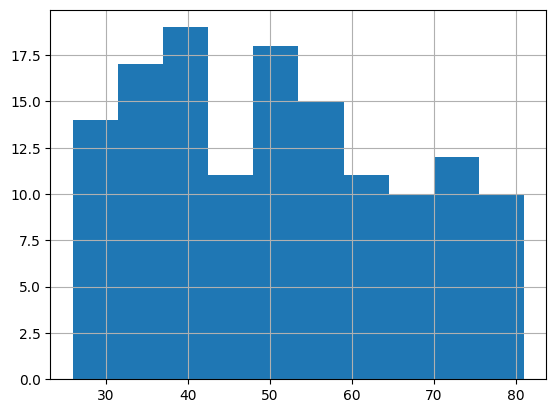

In [ ]:
df['PM2.5'].hist()
plt.show()

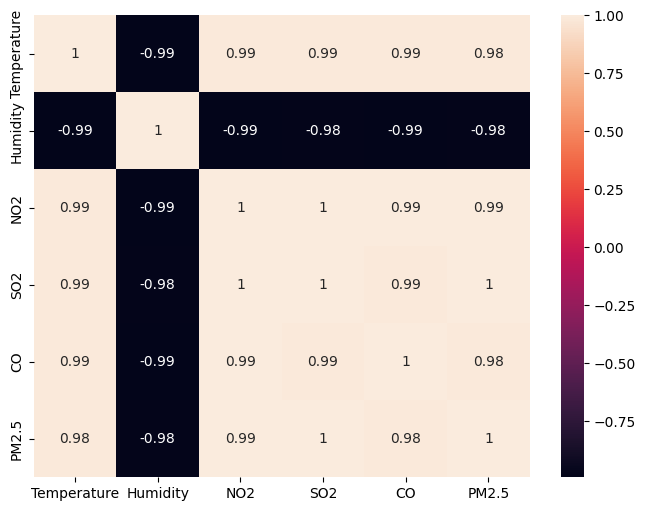

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
X = df[['Temperature','Humidity','NO2','SO2','CO']]
y = df['PM2.5']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = model.predict(X_test)

NameError: name 'model' is not defined

In [ ]:
mae = mean_absolute_error(y_test,predictions)
print("MAE =",mae)

MAE = 0.7803707482993206


In [ ]:
mse = mean_squared_error(y_test,predictions)
print("MSE =",mse)

MSE = 0.8098726719711701


In [ ]:
r2 = r2_score(y_test,predictions)
print("R2 Score =",r2)

R2 Score = 0.9972905635526176


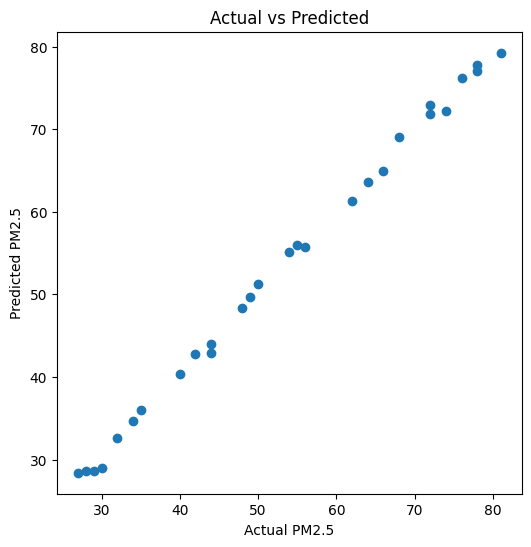

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,predictions)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
new_data = [[32,65,28,12,0.8]]

prediction = model.predict(new_data)

print("Predicted PM2.5 =",prediction[0])

Predicted PM2.5 = 45.13833333333334


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
df = pd.read_csv("air_quality_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'air_quality_dataset.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(df.shape)
print(df.columns)

(170, 6)
Index(['Temperature', 'Humidity', 'NO2', 'SO2', 'CO', 'PM2.5'], dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[['Temperature','Humidity','NO2','SO2','CO']]
y = df['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.6623321661998127
MSE: 0.6461479542474373
R2 Score: 0.9969907983808379


In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(10))

     Actual  Predicted
139      32  31.837500
30       37  36.438667
119      52  50.990000
29       59  58.305286
144      57  55.620000
163      29  29.590000
166      64  62.793000
51       67  68.222833
105      45  44.950000
60       29  29.342500
